# Practica laboratorio
### Ejercicio 1
Con las imágenes contenidas en la carpeta procésalas de manera que obtengan el siguiente resultado

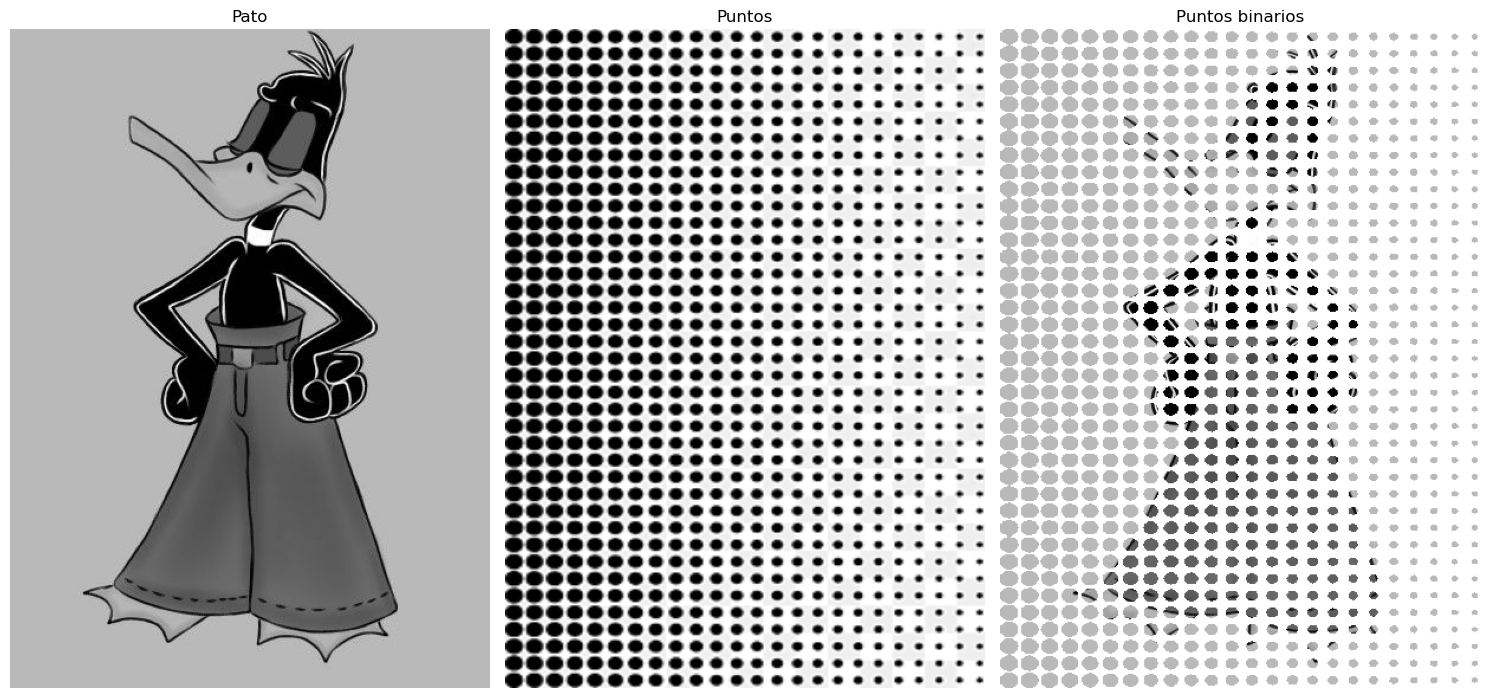

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_lucas_gray = cv2.imread('./images-06/pato.jpg', 0)
img_puntos_gray = cv2.imread('./images-06/puntos.png', 0)

h_pato, w_pato = img_lucas_gray.shape
h_puntos, w_puntos = img_puntos_gray.shape

img_puntos_gray = cv2.resize(img_puntos_gray, (w_pato, h_pato))

_, img_puntos_bin = cv2.threshold(img_puntos_gray, 150, 255, cv2.THRESH_BINARY_INV)

img_resultado = cv2.bitwise_and(img_lucas_gray, img_lucas_gray, mask=img_puntos_bin)

for i in range(h_pato):
    for j in range(w_pato):
        if img_puntos_bin[i, j] == 0:
            img_resultado[i, j] = 255

plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
plt.imshow(img_lucas_gray, cmap='gray')
plt.title('Pato')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_puntos_gray, cmap='gray')
plt.title('Puntos')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_resultado, cmap='gray')
# plt.imshow(img_puntos_bin, cmap='gray')
plt.title('Resultado')
plt.axis('off')

plt.tight_layout()
plt.show()


### Ejercicio 2
Cuenta cuantos objetos de cada color se encuentran en la imagen

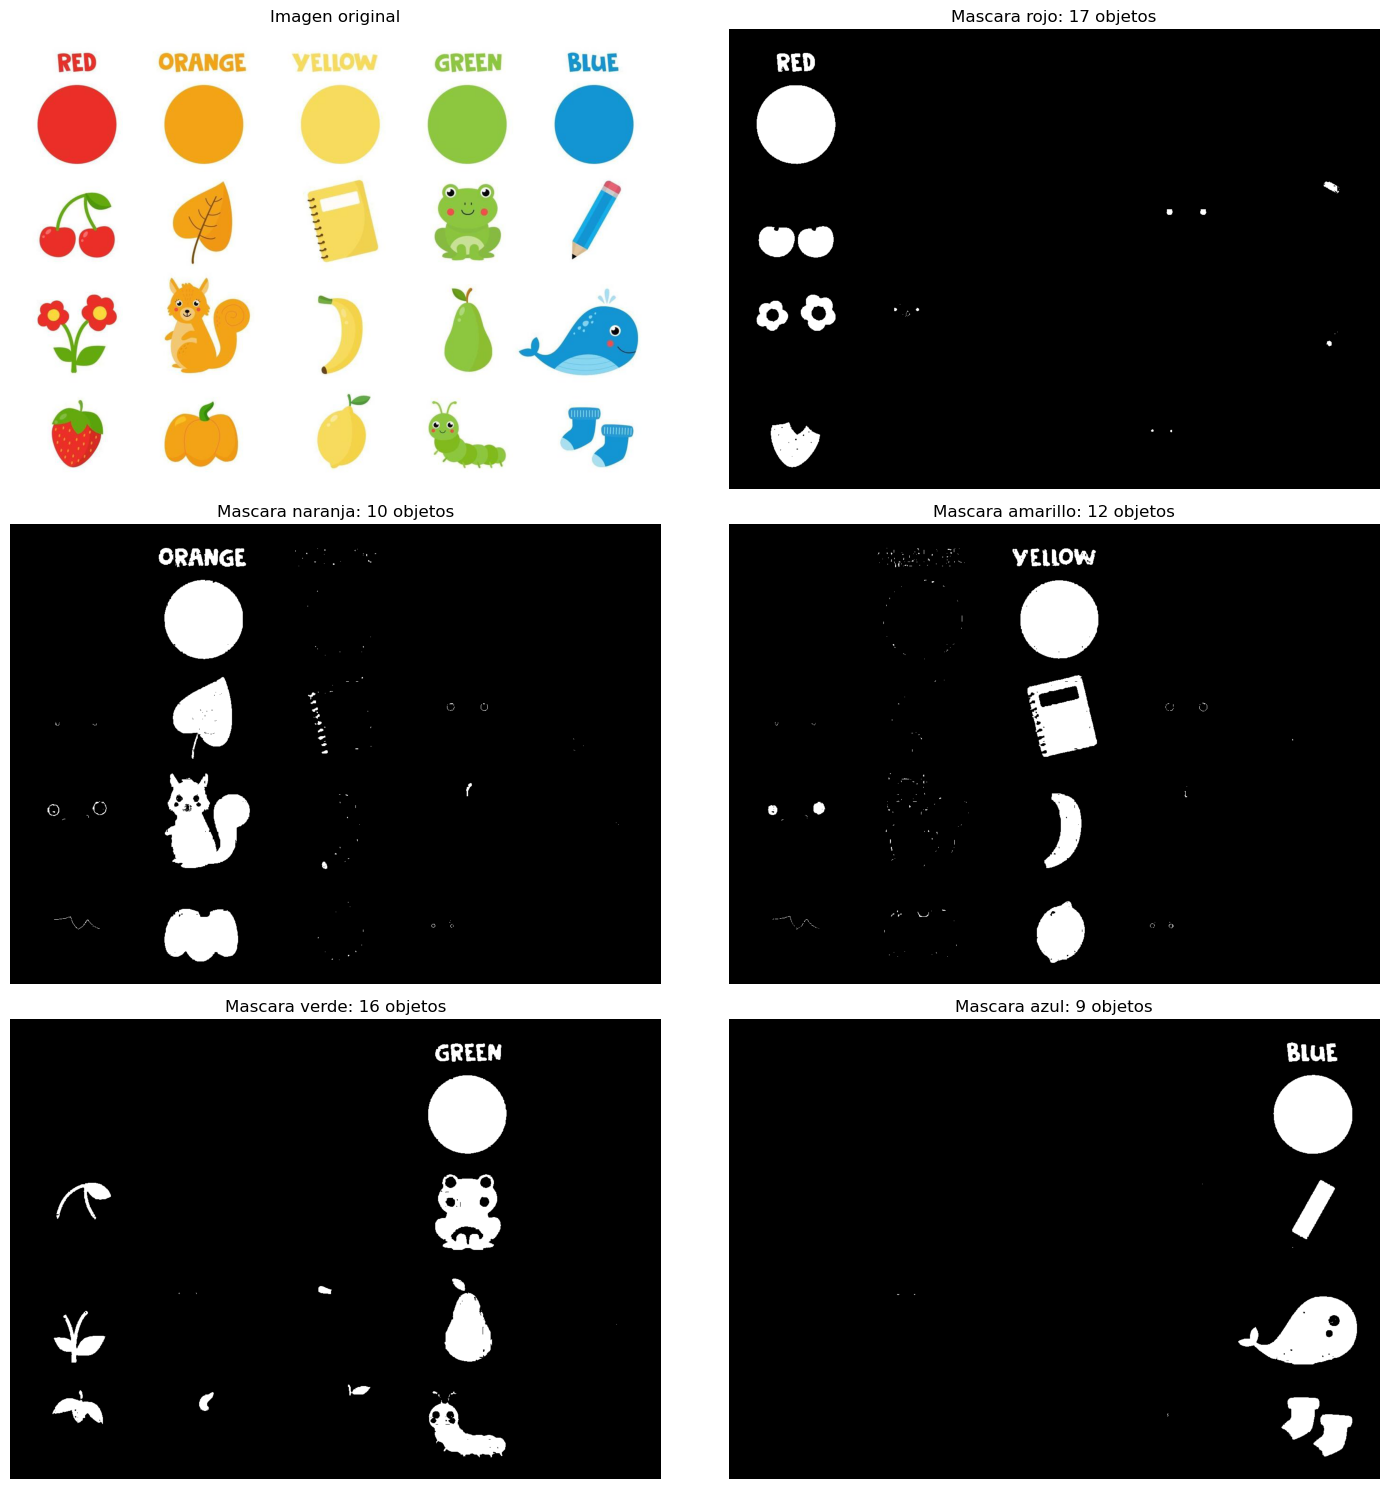

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

rojoBajo1 = np.array([0, 100, 20])
rojoAlto1 = np.array([10, 255, 255])
rojoBajo2 = np.array([175, 100, 20])
rojoAlto2 = np.array([180, 255, 255])

naranjaBajo = np.array([15, 100, 20])
naranjaAlto = np.array([22, 255, 255])

amarilloBajo = np.array([23, 100, 20])
amarilloAlto = np.array([30, 255, 255])

verdeBajo = np.array([40, 100, 20])
verdeAlto = np.array([75, 255, 255])

azulBajo = np.array([90, 100, 20])
azulAlto = np.array([125, 255, 255])

img = cv2.imread('./images-06/colores.jpg')
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# mascaras
mask_rojo1 = cv2.inRange(img_hsv, rojoBajo1, rojoAlto1)
mask_rojo2 = cv2.inRange(img_hsv, rojoBajo2, rojoAlto2)
mask_rojo = cv2.add(mask_rojo1, mask_rojo2)

mask_naranja = cv2.inRange(img_hsv, naranjaBajo, naranjaAlto)
mask_amarillo = cv2.inRange(img_hsv, amarilloBajo, amarilloAlto)
mask_verde = cv2.inRange(img_hsv, verdeBajo, verdeAlto)
mask_azul = cv2.inRange(img_hsv, azulBajo, azulAlto)

def contar_objetos(img_bin, area_minima=50):
  borde, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
  conteo = 0
  for contorno in borde:
    if cv2.contourArea(contorno) > area_minima:
      conteo += 1
  return conteo

conteo_rojo = contar_objetos(mask_rojo, area_minima=10)
conteo_naranja = contar_objetos(mask_naranja, area_minima=500)
conteo_amarillo = contar_objetos(mask_amarillo, area_minima=100)
conteo_verde = contar_objetos(mask_verde, area_minima=100)
conteo_azul = contar_objetos(mask_azul, area_minima=100)

plt.figure(figsize=(15, 15))

plt.subplot(3, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.axis('off')

plt.subplot(3, 2, 2)
plt.imshow(mask_rojo, cmap='gray')
plt.title(f'Mascara rojo: {conteo_rojo} objetos')
plt.axis('off')

plt.subplot(3, 2, 3)
plt.imshow(mask_naranja, cmap='gray')
plt.title(f'Mascara naranja: {conteo_naranja} objetos')
plt.axis('off')

plt.subplot(3, 2, 4)
plt.imshow(mask_amarillo, cmap='gray')
plt.title(f'Mascara amarillo: {conteo_amarillo} objetos')
plt.axis('off')

plt.subplot(3, 2, 5)
plt.imshow(mask_verde, cmap='gray')
plt.title(f'Mascara verde: {conteo_verde} objetos')
plt.axis('off')

plt.subplot(3, 2, 6)
plt.imshow(mask_azul, cmap='gray')
plt.title(f'Mascara azul: {conteo_azul} objetos')
plt.axis('off')

plt.tight_layout()
plt.show()

### Ejercicio 3
Estás trabajando en un proyecto de reconocimiento de rostros y necesitas detectar los bordes de las caras en las imágenes. Explique cómo aplicaría el operador de detección de bordes de Canny y aplícalo con un código en Python en jupyter

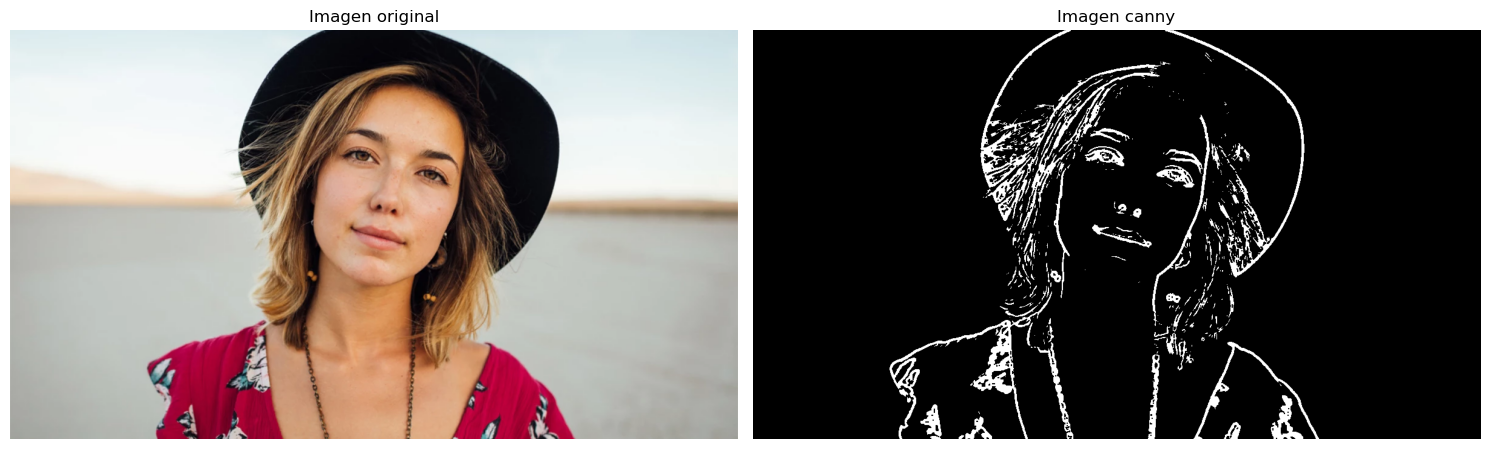

In [82]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sobel_mejorado(img, tam_kernel=3, umbral=30):
  img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  suavizado = cv2.GaussianBlur(img_gray, (3, 3), 0)
  
  sobel_x = cv2.Sobel(suavizado, cv2.CV_64F, 1, 0, ksize=tam_kernel)
  sobel_y = cv2.Sobel(suavizado, cv2.CV_64F, 0, 1, ksize=tam_kernel)
  
  # magnitud = cv2.addWeighted(np.abs(sobel_x), 0.7, np.abs(sobel_y), 0.7, 0)
  magnitud = np.sqrt(sobel_x**2 + sobel_y**2)
  magnitud = cv2.normalize(magnitud, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)

  # _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY) # Agregariamos otsu
  _, bordes = cv2.threshold(magnitud, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) # Agregariamos otsu

  # Unir bordes rotos
  kernel_morf = np.ones((2, 2), np.uint8)
  bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_morf)
  
  return bordes

img = cv2.imread('./images-06/persona.jpg')
bordes = sobel_mejorado(img)

plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bordes, cmap='gray')
plt.title('Imagen canny')
plt.axis('off')

plt.tight_layout()
plt.show()